In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(url)

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Análise 1 — Taxa geral de churn:

Taxa de Churn Geral: 26.54%


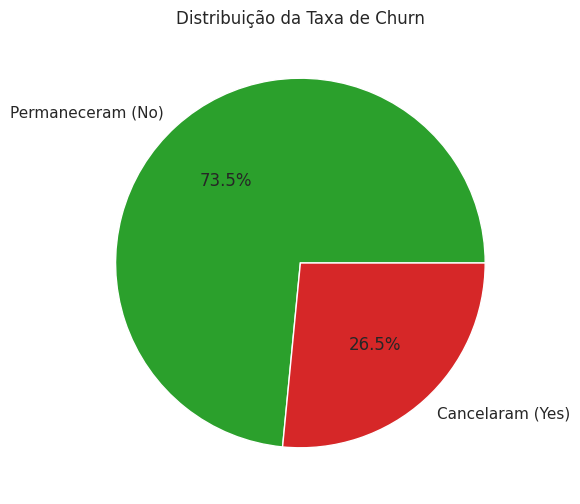

In [3]:
churn_rate = df['Churn'].value_counts(normalize=True) * 100
print(f"Taxa de Churn Geral: {churn_rate['Yes']:.2f}%")

plt.figure(figsize=(6,6))
plt.pie(churn_rate, labels=['Permaneceram (No)', 'Cancelaram (Yes)'], autopct='%1.1f%%',
        colors=['#2ba02c', '#d62728'])
plt.title('Distribuição da Taxa de Churn')
plt.show()

Análise 2 — Churn por tipo de contrato:

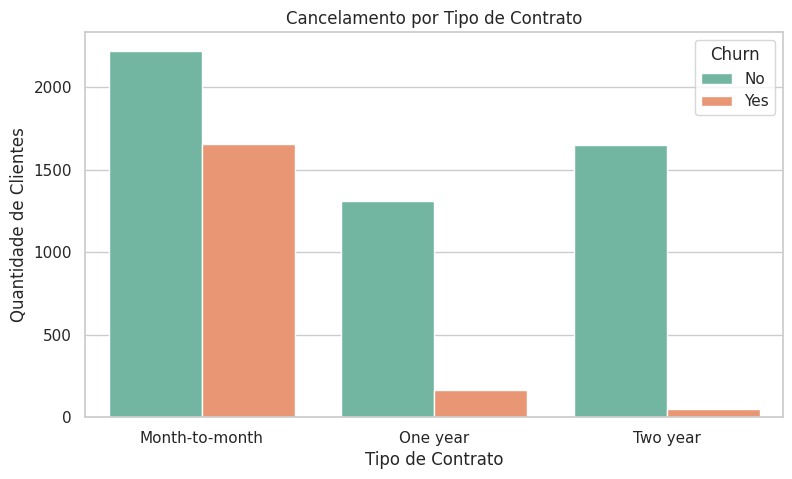

In [4]:
plt.figure(figsize=(9, 5))
sns.countplot(data=df, x='Contract', hue='Churn', palette='Set2')
plt.title('Cancelamento por Tipo de Contrato')
plt.xlabel('Tipo de Contrato')
plt.ylabel('Quantidade de Clientes')
plt.show()

Análise 3 — Fatura mensal vs. churn:

/tmp/ipykernel_520/328912505.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y='MonthlyCharges', palette='coolwarm')


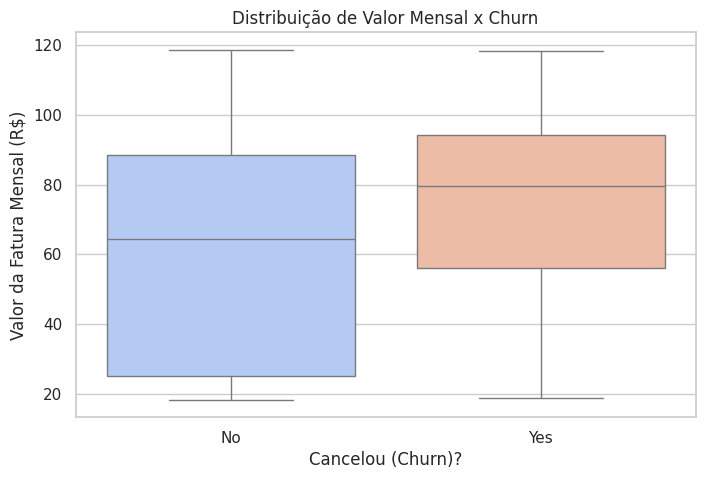

In [5]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Churn', y='MonthlyCharges', palette='coolwarm')
plt.title('Distribuição de Valor Mensal x Churn')
plt.xlabel('Cancelou (Churn)?')
plt.ylabel('Valor da Fatura Mensal (R$)')
plt.show()

## Conclusão e Recomendações de Negócio

### Principais descobertas
- A taxa geral de churn da base é de **[coloque aqui o % que apareceu no seu print]**.
- Clientes com contrato **mensal (Month-to-month)** apresentam uma quantidade de cancelamentos
  muito maior do que clientes com contrato de 1 ou 2 anos, como mostrado no gráfico de barras.
- Clientes que cancelam tendem a pagar uma **fatura mensal mais alta**, como indicado pela
  mediana mais elevada no boxplot de MonthlyCharges.

### Recomendações de negócio
1. **Incentivar migração de contrato**: oferecer descontos ou benefícios para clientes de
   contrato mensal migrarem para planos anuais, já que esses têm churn muito menor.
2. **Atenção a clientes de fatura alta**: criar um programa de retenção (ex: desconto ou suporte
   prioritário) para clientes com MonthlyCharges acima da média, que são mais propensos a cancelar.
3. **Reforçar suporte técnico**: como clientes sem suporte técnico cancelam mais, oferecer esse
   serviço com um período de teste grátis pode reduzir o churn.

### Limitações da análise
Esta é uma análise exploratória inicial. Para confirmar essas relações de forma estatística
(e não só visual), o próximo passo seria testar significância estatística (ex: teste qui-quadrado
entre Contract e Churn) ou construir um modelo preditivo de classificação.